In [24]:
import pandas as pd
import sys
sys.path.append('/home/azureuser/cloudfiles/code/Users/manhductranvu/reeval-multi/mirt-official') 
from load_params import load_and_rotate

resmat = pd.read_pickle("../data/resmat.pkl")

theta, a, b = load_and_rotate(rotation=None, model_path='./output/mirt_model_k19_auc89.pt')

# varimax, oblimax, quartimax, equamax, geomin_ort, promax, oblimin, quartimin, geomin_obl

# Step 1: Get the final theta tensor into a NumPy array
theta_abilities = theta
# Step 2: Create a labeled pandas DataFrame
# Use the model names from your original resmat for the index
model_names = resmat.index
factor_names = [f'F{i+1}' for i in range(theta.shape[1])]
ability_df = pd.DataFrame(theta_abilities, index=model_names, columns=factor_names)

--- Loading from Cache ---
Loaded cached theta shape: (183, 19)
Loaded cached a shape: (78712, 19)
Loaded cached b shape: (78712,)



In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sys.path.append('..') 
import style
plt.rcParams.update(style.rcparams)

a_df_scenarios = pd.DataFrame(a, index=resmat.columns.get_level_values('scenario'), columns=factor_names)
# Group by similar index values and calculate mean
a_df_grouped = a_df_scenarios.groupby(a_df_scenarios.index).mean().dropna()


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_77177/81466236.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a_df_grouped = a_df_scenarios.groupby(a_df_scenarios.index).mean().dropna()


In [ ]:
import sys
sys.path.append('.')
import pandas as pd

resmat = pd.read_pickle("../data/resmat.pkl")

# Extract names for labeling
item_names = resmat.columns.get_level_values('input.text').to_list()
model_names = resmat.index.to_list()

df_theta = pd.DataFrame(theta, index=model_names, columns=factor_names) + 5
df_a = pd.DataFrame(a, index=resmat.columns.get_level_values('scenario'), columns=factor_names)

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_77177/1073814106.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a_df_grouped = a_df_scenarios.groupby(a_df_scenarios.index).mean().dropna()


Original a_df shape: (78712, 19)
Grouped a_df shape: (22, 19)
Number of unique scenarios: 22


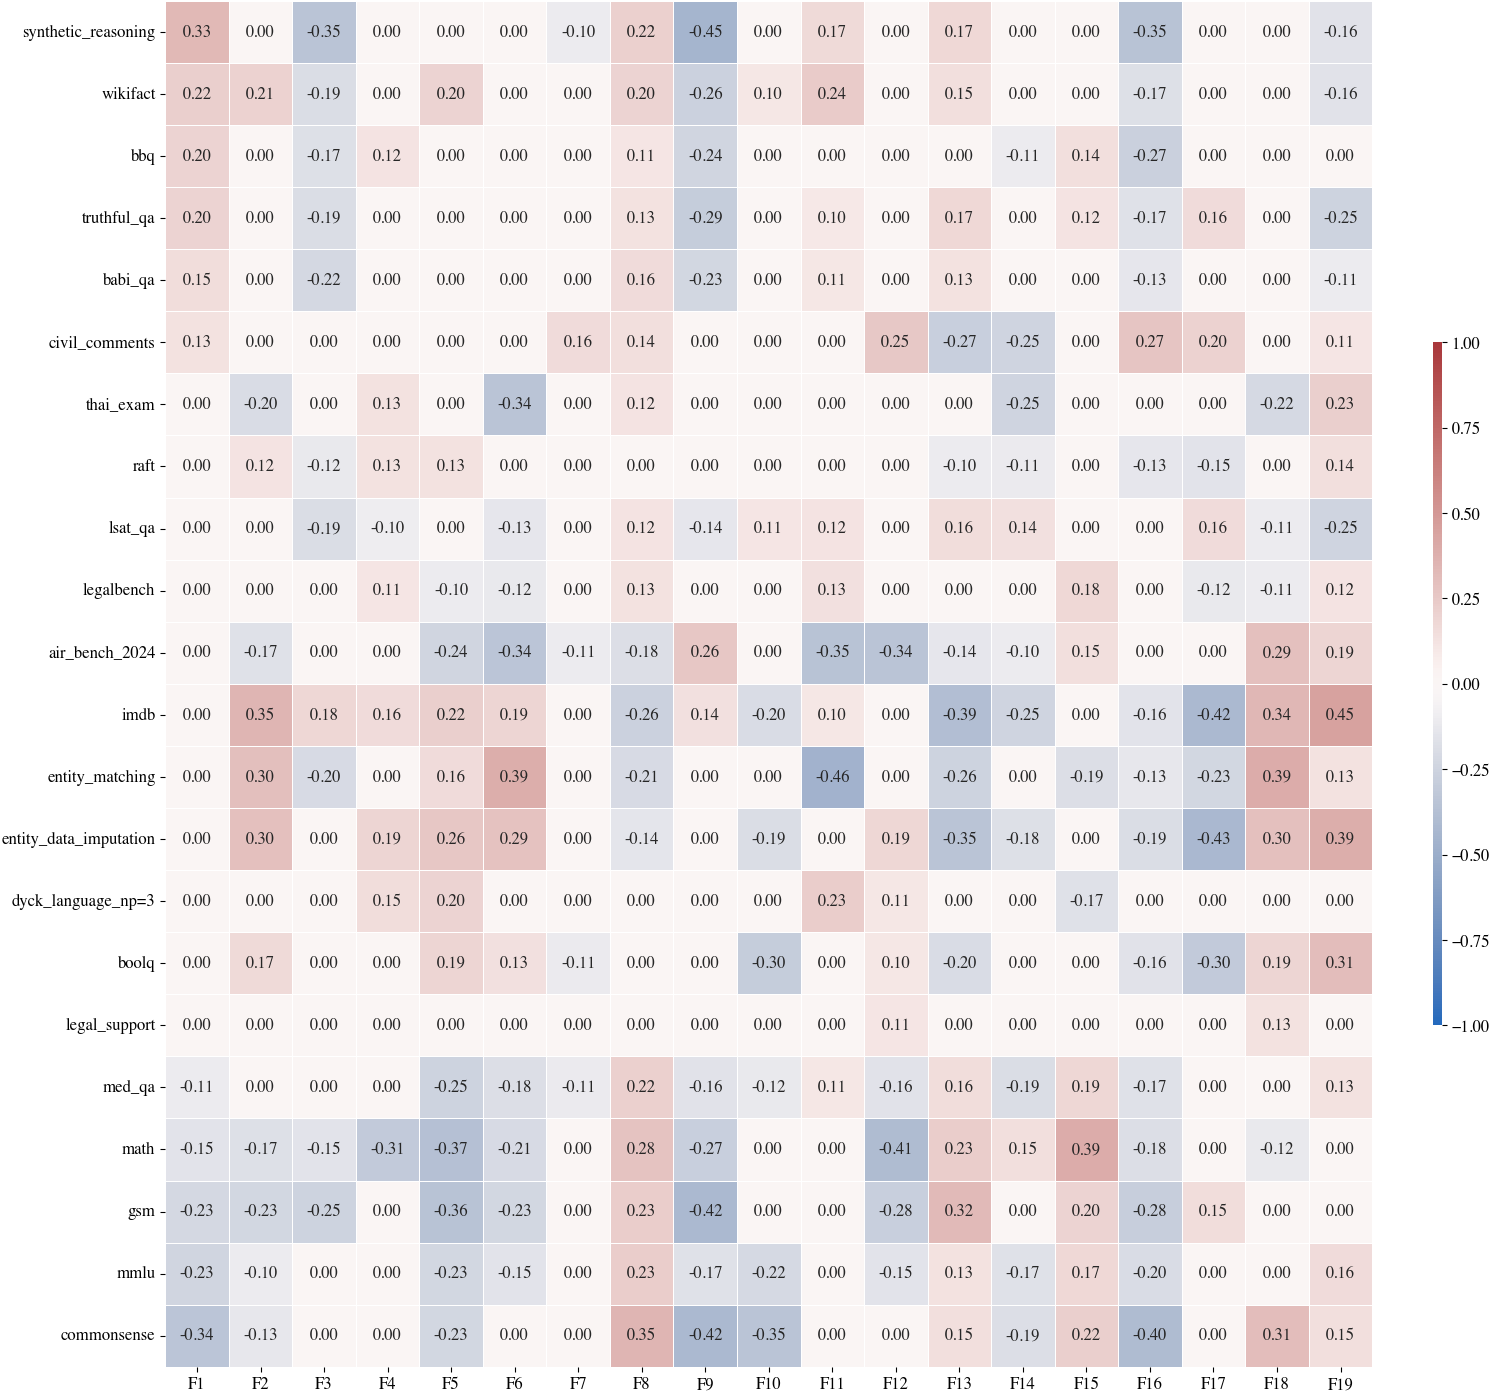

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


sys.path.append('..') 
import style
plt.rcParams.update(style.rcparams)

factor_names = [f'F{i+1}' for i in range(df_a.shape[1])]

a_df_scenarios = pd.DataFrame(df_a.values, index=resmat.columns.get_level_values('scenario'), columns=factor_names)
# Group by similar index values and calculate mean
a_df_grouped = a_df_scenarios.groupby(a_df_scenarios.index).mean().dropna()

# Check the resulting shape
print(f"Original a_df shape: {a_df_scenarios.shape}")
print(f"Grouped a_df shape: {a_df_grouped.shape}")
print(f"Number of unique scenarios: {len(a_df_grouped.index)}")

inspection = a_df_grouped.copy()
inspection[abs(inspection) < 0.1] = 0

# 1. Order rows by sum (scenarios with highest total loadings first) 
# row_sums = inspection.abs().sum(axis=1)
# row_order = row_sums.sort_values(ascending=False).index

# 2. Reorder inspection matrix - only reorder rows, keep columns in original order
# ordered_inspection = inspection.loc[row_order, :]
ordered_inspection = inspection.sort_values(by='F1', ascending=False)

# You can adjust figsize to make the plot larger or smaller for better readability.
fig, ax = plt.subplots(figsize=(15, 14))

# 2. Generate the clustered heatmap
# sns.heatmap is the core function here.
sns.heatmap(
    ordered_inspection,     # The clustered data to plot
    annot=True,       # Write the data value in each cell
    fmt=".2f",        # Use two decimal places for annotations
    cmap='vlag',  # Use the 'vlag' color map (blue-white-red)
    linewidths=.5,    # Add lines between cells
    ax=ax,
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={'shrink': 0.5, 'aspect': 75}
)

# 3. Add titles and labels for clarity
ax.set_xlabel('')
ax.set_ylabel('')

# 4. Ensure labels are not cut off
# plt.tight_layout()

# 5. Display the plot
plt.show()

# To save the figure to a file, uncomment the line below
fig.savefig('../result/clustered_heatmap_.pdf', bbox_inches='tight')

In [28]:
import pandas as pd

# Standardize residuals (F2...F19), keep F1 as-is
theta_std = df_theta.copy()
for col in df_theta.columns[1:]:  # skip F1
    theta_std[col] = (df_theta[col] - df_theta[col].mean()) / df_theta[col].std()

# Build composite scores: F1 + standardized Fj
scores = {}
scores['score_1'] = pd.Series(df_theta['F1'], index=resmat.index)

for j in range(2, 20):  # F2 to F19
    scores[f'score_{j}'] = pd.Series(
        df_theta['F1'] + theta_std[f'F{j}'],
        index=resmat.index
    )

# Convert to DataFrame if you want a single table
scores_df = pd.DataFrame(scores)


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_77177/1078935430.py:208: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


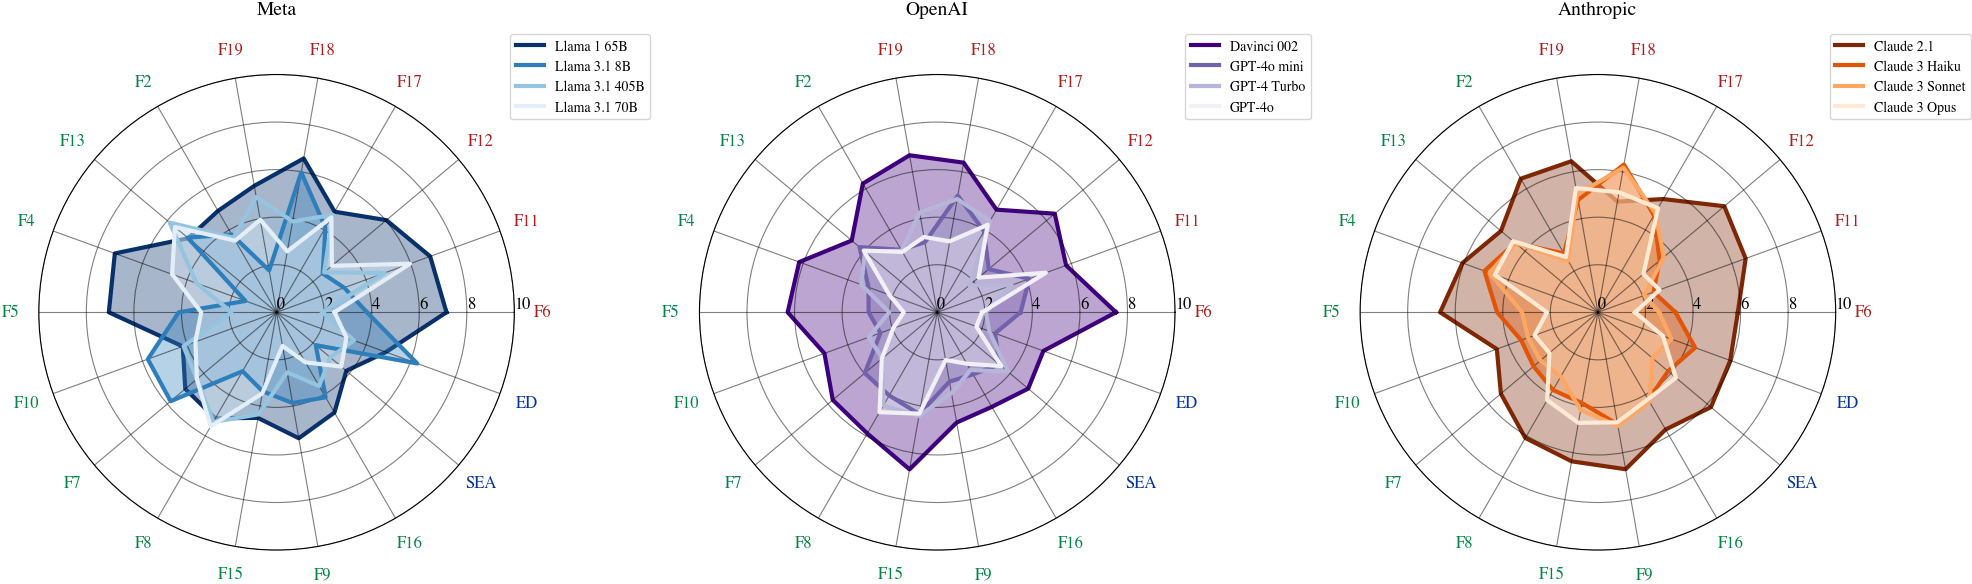

Selected models for radar charts:

META:
  Llama 1 65B
  Llama 3.1 8B
  Llama 3.1 405B
  Llama 3.1 70B

OPENAI:
  Davinci 002
  GPT-4o mini
  GPT-4 Turbo
  GPT-4o

ANTHROPIC:
  Claude 2.1
  Claude 3 Haiku
  Claude 3 Sonnet
  Claude 3 Opus


In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from math import pi
import sys
sys.path.append('..')
import style
plt.rcParams.update(style.rcparams)

common_indices = [
    'anthropic/claude-3-sonnet-20240229', 'anthropic/claude-3-opus-20240229', 'anthropic/claude-3-haiku-20240307', 'anthropic/stanford-online-all-v4-s3',
    'meta/llama-3.1-8b-instruct-turbo', 'meta/llama-3.1-70b-instruct-turbo', 'meta/llama-3.1-405b-instruct-turbo', 'meta/llama-65b',
    'openai/gpt-4o-2024-05-13', 'openai/gpt-4o-mini-2024-07-18', 'openai/gpt-4-turbo-2024-04-09', 'openai/text-davinci-002'
]

# EDIT: Added a mapping from code names to formal display names
model_name_mapping = {
    'anthropic/claude-3-sonnet-20240229': 'Claude 3 Sonnet',
    'anthropic/claude-3-opus-20240229': 'Claude 3 Opus',
    'anthropic/claude-3-haiku-20240307': 'Claude 3 Haiku',
    'anthropic/stanford-online-all-v4-s3': 'Claude 2.1',
    'meta/llama-3.1-8b-instruct-turbo': 'Llama 3.1 8B',
    'meta/llama-3.1-70b-instruct-turbo': 'Llama 3.1 70B',
    'meta/llama-3.1-405b-instruct-turbo': 'Llama 3.1 405B',
    'meta/llama-65b': 'Llama 1 65B',
    'openai/gpt-4o-2024-05-13': 'GPT-4o',
    'openai/gpt-4o-mini-2024-07-18': 'GPT-4o mini',
    'openai/gpt-4-turbo-2024-04-09': 'GPT-4 Turbo',
    'openai/text-davinci-002': 'Davinci 002'
}


scores_mapping = {
    # 'F1': scores['score_1'],
    'F2': scores['score_2'],
    'F3': scores['score_3'],
    'F4': scores['score_4'],
    'F5': scores['score_5'],
    'F6': scores['score_6'],
    'F7': scores['score_7'],
    'F8': scores['score_8'],
    'F9': scores['score_9'],
    'F10': scores['score_10'],
    'F11': scores['score_11'],
    'F12': scores['score_12'],
    'F13': scores['score_13'],
    'F14': scores['score_14'],
    'F15': scores['score_15'],
    'F16': scores['score_16'],
    'F17': scores['score_17'],
    'F18': scores['score_18'],
    'F19': scores['score_19'],
}

skill_scores = pd.DataFrame(scores_mapping)

# Psychometric Groupings of AI Capability Dimensions

reasoning = {
    'F6': ('Abstract Reasoning', 'F6'),
    'F11': ('General Problem Solving', 'F11'),
    'F12': ('Procedural and Generative Planning', 'F12'),
    'F17': ('Complex Reasoning', 'F17'),
    'F18': ('Application of External Knowledge', 'F18'),
    'F19': ('Formal Reasoning and Procedural Adherence', 'F19')
}

comprehension = {
    'F2': ('In-Context Retrieval', 'F2'),
    'F13': ('In-Context Analysis', 'F13'),
    'F4': ('Literal Reading Comprehension', 'F4'),
    'F5': ('Procedural Comprehension', 'F5'),
    'F10': ('Descriptive Comprehension', 'F10'),
    'F7': ('Dense and Formal Language Comprehension', 'F7'),
    'F8': ('Internal Knowledge and Application', 'F8'),
    'F15': ('General Verbal Comprehension', 'F15'),
    'F9': ('Verbal Fluency', 'F9'),
    'F16': ('Informal Language Comprehension', 'F16')
}

style = {
    'F3': ('Safet and Ethics Alignment', 'SEA'),
    'F14': ('Expansive Discourse', 'ED')
}

# --- START OF CHANGE 1: Define colors and map skills to groups ---

# 1. Define a color for each capability group
group_colors = {
    "Reasoning": '#B31B1B',
    "Comprehension": '#008542',
    "Style": '#0033A0'
}

# 2. Create a reverse map from a skill ('F2') to its group name
skill_to_group_map = {}
for group_name, skills_dict in {
    "Reasoning": reasoning,
    "Comprehension": comprehension,
    "Style": style
}.items():
    for skill_code in skills_dict:
        skill_to_group_map[skill_code] = group_name



all_capability_dims = {
    **reasoning,
    **comprehension,
    **style
}

skill_scores = skill_scores[list(all_capability_dims.keys())]
abbreviated_labels = [all_capability_dims[col][1] for col in skill_scores.columns]


# 3. Create a list of colors that matches the order of the labels
label_colors = [group_colors[skill_to_group_map[col]] for col in skill_scores.columns]


skill_scores = skill_scores.loc[common_indices]


# 4. Update the function to accept and apply label colors
def create_radar_chart(data, labels, title, ax, colors=None, model_names=None, label_colors=None):
    N = len(labels)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(data)))
    for i, (model_data, color) in enumerate(zip(data, colors)):
        values = model_data.tolist()
        values += values[:1]
        model_name = model_names[i] if model_names else f'Model {i+1}'
        display_name = model_name.split('/')[-1] if '/' in model_name else model_name
        ax.plot(angles, values, '-', linewidth=3, label=display_name, color=color, alpha=1, zorder=i + 1)
        ax.fill(angles, values, color=color, alpha=0.35)
    ax.tick_params(pad=10)
    range_ax = range(0, 11, 2)
    ax.set_ylim(range_ax[0], range_ax[-1])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=12, weight='bold')
    
    # This is the new part: Apply the colors to the tick labels
    if label_colors:
        for xtick, color in zip(ax.get_xticklabels(), label_colors):
            xtick.set_color(color)
            
    ax.grid(True, alpha=0.5, color='black')
    ax.set_rgrids(range_ax, angle=0, labels=range_ax, fontsize=12)
    ax.set_rmin(range_ax[0])



companies = { 'meta': [], 'openai': [], 'anthropic': [] }
common_models = skill_scores.dropna().index
for model in common_models:
    if model.startswith('meta/'): companies['meta'].append(model)
    elif model.startswith('openai/'): companies['openai'].append(model)
    elif model.startswith('anthropic/'): companies['anthropic'].append(model)

def select_top_models(models, n=6, explicit_models=None):
    if not models: return []
    result = []
    if explicit_models:
        result = [model for model in explicit_models if model in models]
    if len(result) >= n: return result[:n]
    model_scores = skill_scores.loc[models].mean(axis=1).sort_values(ascending=False)
    remaining_slots = n - len(result)
    for model in model_scores.index:
        if model not in result:
            result.append(model)
            remaining_slots -= 1
            if remaining_slots == 0: break
    return result

selected_models = {
    company: select_top_models(models, n=6) for company, models in companies.items()
}

fig, axes = plt.subplots(1, 3, figsize=(20, 12), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

company_names = ['Meta', 'OpenAI', 'Anthropic']
company_keys = ['meta', 'openai', 'anthropic']

for i, (company_key, company_name) in enumerate(zip(company_keys, company_names)):
    models = selected_models[company_key]
    if models:
        model_data = skill_scores.loc[models].values
        display_names = [model_name_mapping.get(model, model) for model in models]
        if company_key == 'meta':
            colors = plt.cm.Blues_r(np.linspace(0, 0.9, len(models)))
        elif company_key == 'openai':
            colors = plt.cm.Purples_r(np.linspace(0, 0.9, len(models)))
        elif company_key == 'anthropic':
            colors = plt.cm.Oranges_r(np.linspace(0, 0.9, len(models)))
        
        create_radar_chart(model_data, abbreviated_labels, company_name, axes[i],
                           colors=colors, model_names=display_names, label_colors=label_colors)
        
        axes[i].set_title(company_name, size=14, weight='bold', pad=20)
        axes[i].legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
    else:
        axes[i].text(0.5, 0.5, f'No {company_name} models found', transform=axes[i].transAxes, ha='center', va='center')
        axes[i].set_title(company_name, size=14, weight='bold', pad=20)

plt.tight_layout()
plt.savefig('../result/model_families_all_skill_radar_charts.pdf', bbox_inches='tight')
plt.show()

print("Selected models for radar charts:")
for company, models in selected_models.items():
    print(f"\n{company.upper()}:")
    for model in models:
        formal_name = model_name_mapping.get(model, model)
        print(f"  {formal_name}")